In [29]:
import pandas as pd
df_76ers = pd.read_csv('cleaned76ersData.csv')
df_eagles = pd.read_csv('cleanedEaglesData.csv')
df_flyers = pd.read_csv('cleanedFlyersData.csv')
df_phillies = pd.read_csv('cleanedPhilliesData.csv')


In [30]:
df_76ers.columns

Index(['Game', 'Day', 'Date', 'StartTime', 'LOG', 'EndTime', 'Home',
       'Attendance', 'Opp', 'TeamScore', 'OppScore', 'PointDiff', 'Win', 'OT',
       'Season', 'Wins', 'Losses', 'Streak', 'Rivalry', 'Celtics', 'Knicks'],
      dtype='object')

In [31]:
df_eagles.columns

Index(['Game', 'Day', 'Date', 'StartTime', 'xEndTime', 'Home', 'Opp',
       'TeamScore', 'OppScore', 'PointDiff', 'DefTO', 'OffTO', 'TODiff', 'Win',
       'OT', 'Season', 'Wins', 'Losses', 'Streak', 'Rivalry', 'Giants',
       'Cowboys', 'RegularSeason', 'Division', 'ConfChamp', 'SuperBowl'],
      dtype='object')

In [32]:
df_flyers.columns

Index(['Game', 'Day', 'Date', 'xStartTime', 'xLOG', 'xEndTime', 'Home',
       'Attendance', 'Opp', 'TeamScore', 'OppScore', 'PointDiff', 'Win', 'OT',
       'SO', 'Season', 'Wins', 'Losses', 'Streak', 'Rivalry', 'Penguins',
       'Rangers', 'Devils', 'RegularSeason', 'ConfQF'],
      dtype='object')

In [33]:
df_phillies.columns

Index(['Game', 'Day', 'Date', 'StartTime', 'LOG', 'EndTime', 'DayGame', 'Rank',
       'CLI', 'Home', 'Attendance', 'Opp', 'TeamScore', 'OppScore',
       'PointDiff', 'Win', 'Walkoff', 'Season', 'Streak', 'Rivalry', 'Mets',
       'Braves'],
      dtype='object')

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

games by day of week

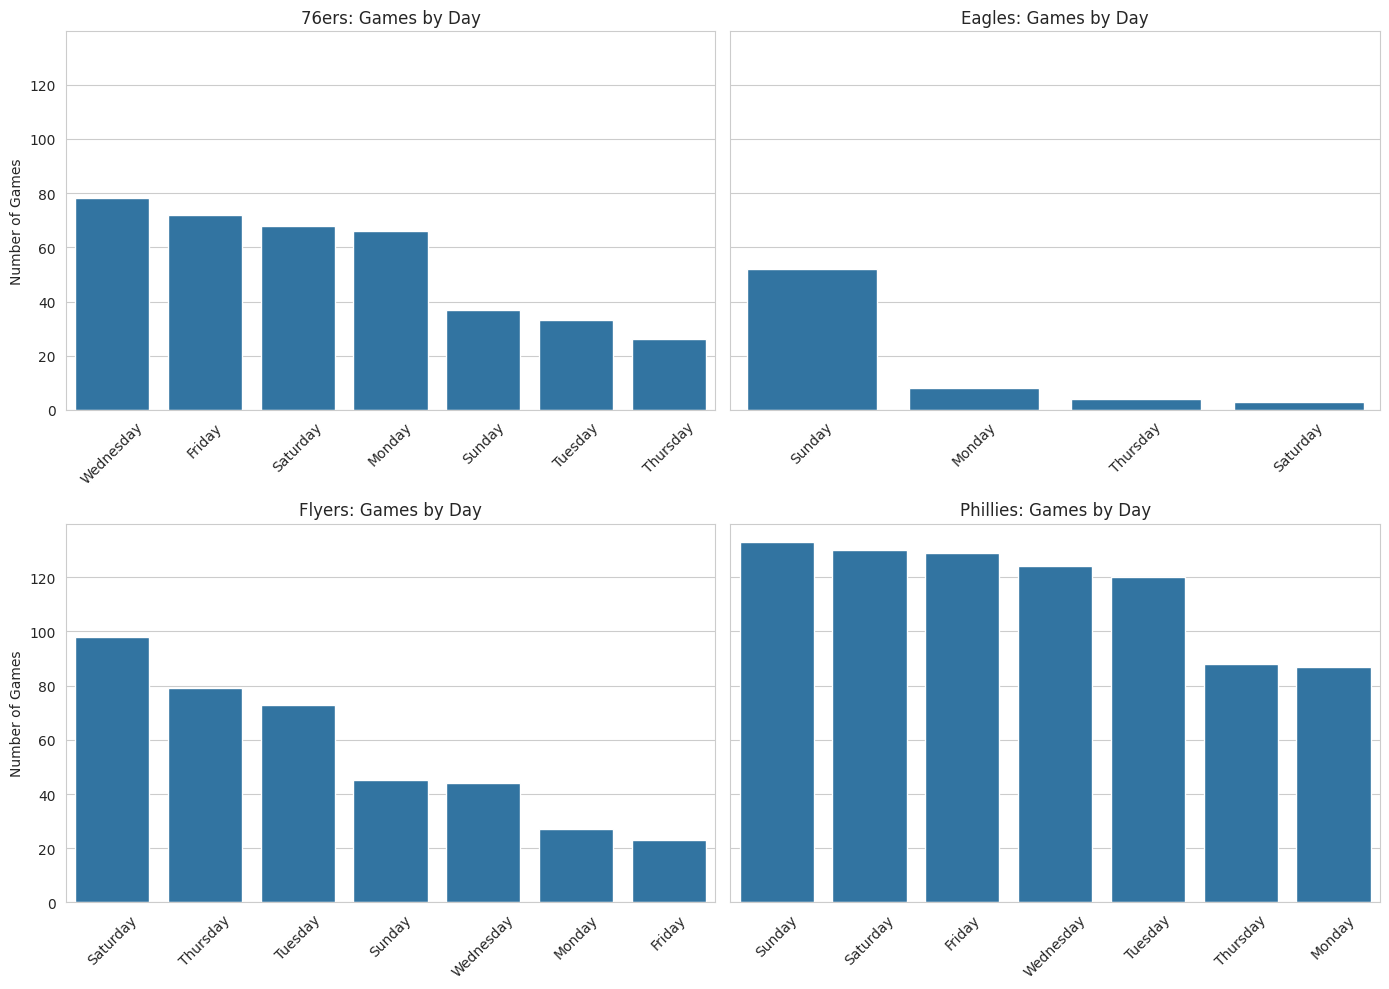

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=True)

teams = {
    "76ers": df_76ers,
    "Eagles": df_eagles,
    "Flyers": df_flyers,
    "Phillies": df_phillies
}

for ax, (team_name, df) in zip(axes.flatten(), teams.items()):

    # count games by actual values in Day column
    counts = df["Day"].value_counts()

    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"{team_name}: Games by Day")
    ax.set_xlabel("")
    ax.set_ylabel("Number of Games")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

home vs away distribution

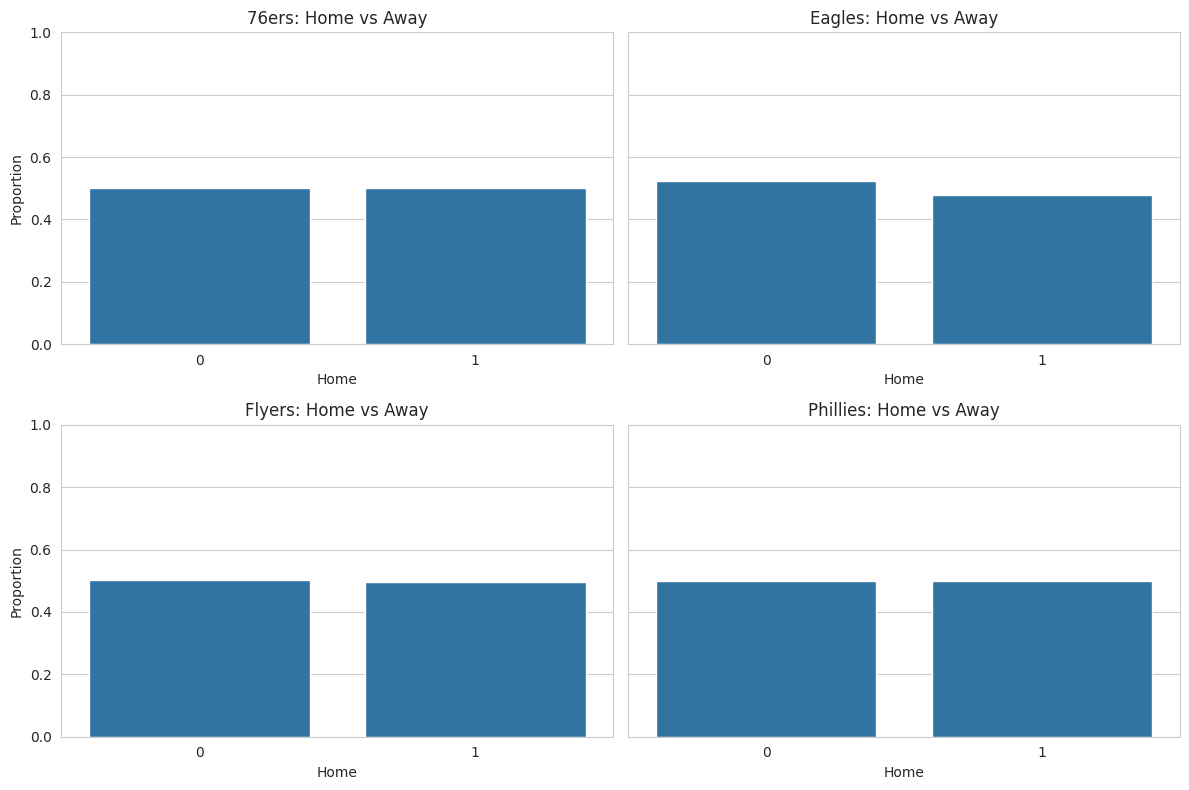

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)

for ax, (team_name, df) in zip(axes.flatten(), teams.items()):
    home_pct = df["Home"].value_counts(normalize=True)

    sns.barplot(x=home_pct.index, y=home_pct.values, ax=ax)
    ax.set_title(f"{team_name}: Home vs Away")
    ax.set_ylim(0,1)
    ax.set_ylabel("Proportion")

plt.tight_layout()
plt.show()

point diff -> intensity hypothesis, so close games might matter

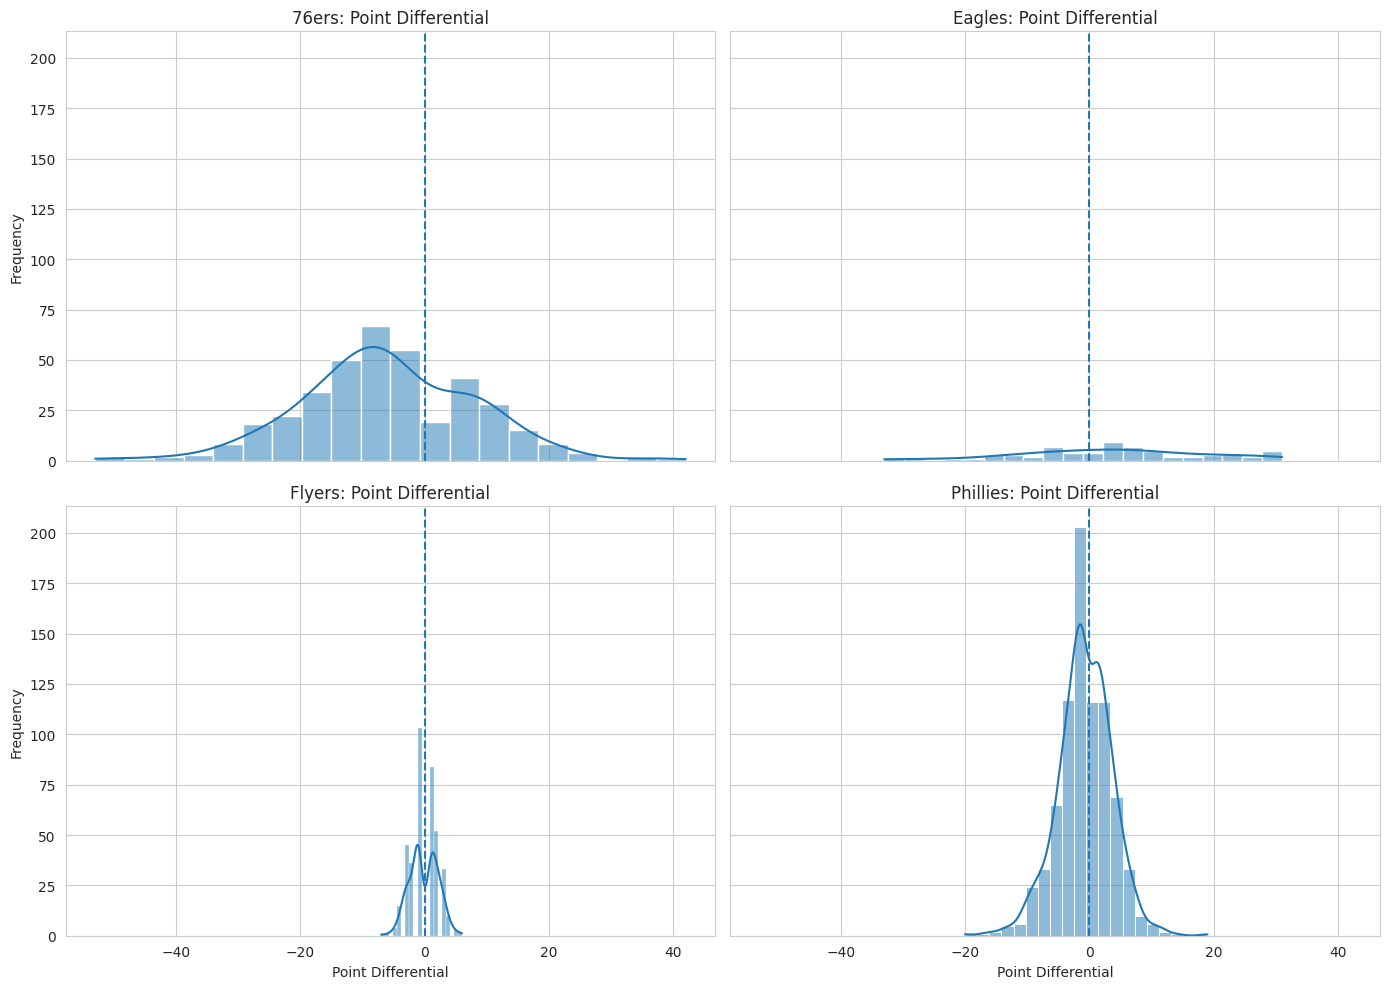

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex=True, sharey=True)

for ax, (team_name, df) in zip(axes.flatten(), teams.items()):
    sns.histplot(df["PointDiff"], bins=20, kde=True, ax=ax)
    ax.axvline(0, linestyle="--")  # wins vs losses divider
    ax.set_title(f"{team_name}: Point Differential")
    ax.set_xlabel("Point Differential")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

win loss proportion

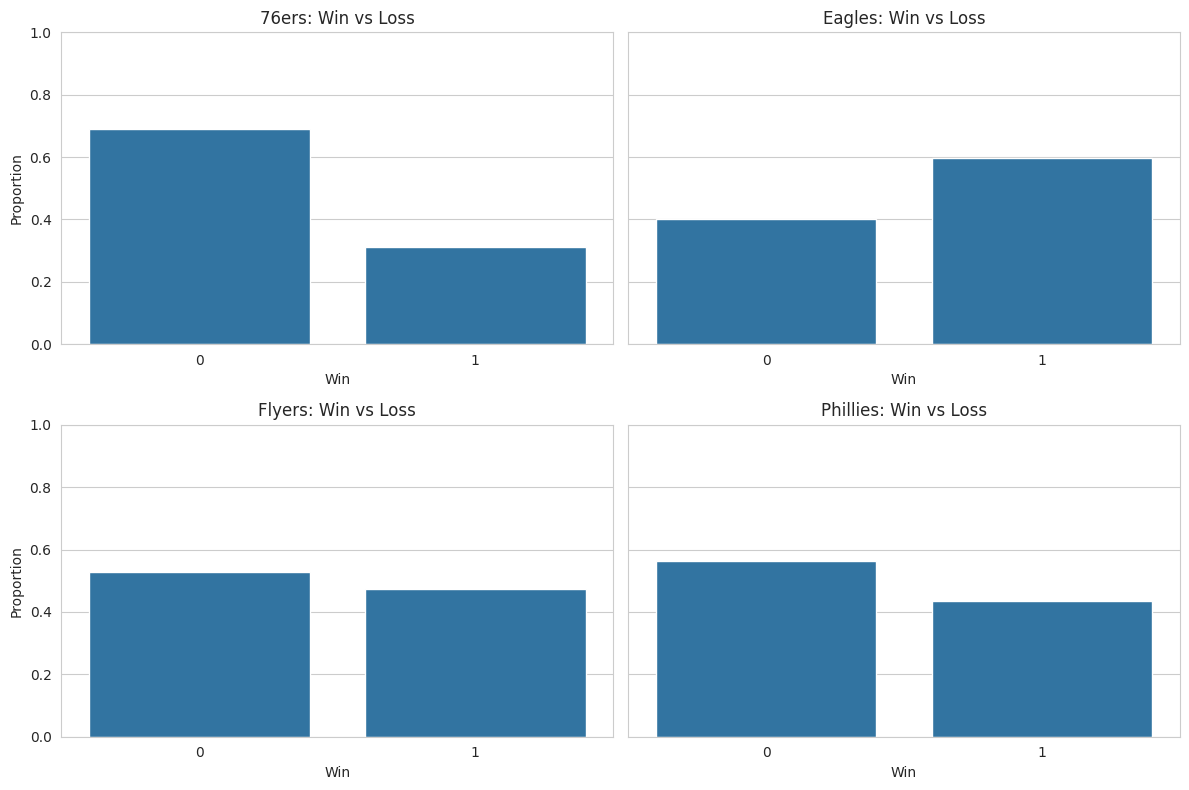

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)

for ax, (team_name, df) in zip(axes.flatten(), teams.items()):
    win_pct = df["Win"].value_counts(normalize=True)

    sns.barplot(x=win_pct.index, y=win_pct.values, ax=ax)
    ax.set_title(f"{team_name}: Win vs Loss")
    ax.set_ylim(0,1)
    ax.set_ylabel("Proportion")

plt.tight_layout()
plt.show()

rivalry game freq

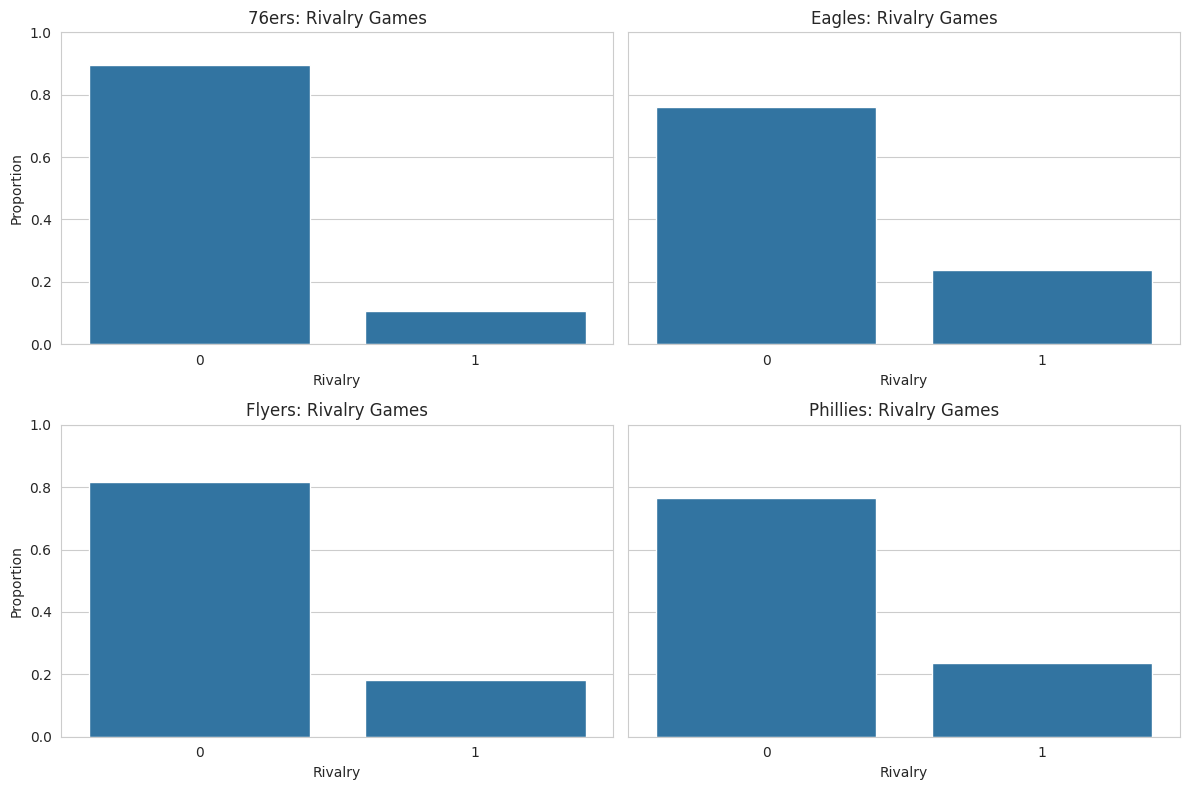

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)

for ax, (team_name, df) in zip(axes.flatten(), teams.items()):
    if "Rivalry" in df.columns:
        rival_pct = df["Rivalry"].value_counts(normalize=True)
        sns.barplot(x=rival_pct.index, y=rival_pct.values, ax=ax)
        ax.set_ylim(0,1)
        ax.set_title(f"{team_name}: Rivalry Games")
        ax.set_ylabel("Proportion")
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

attendence dist

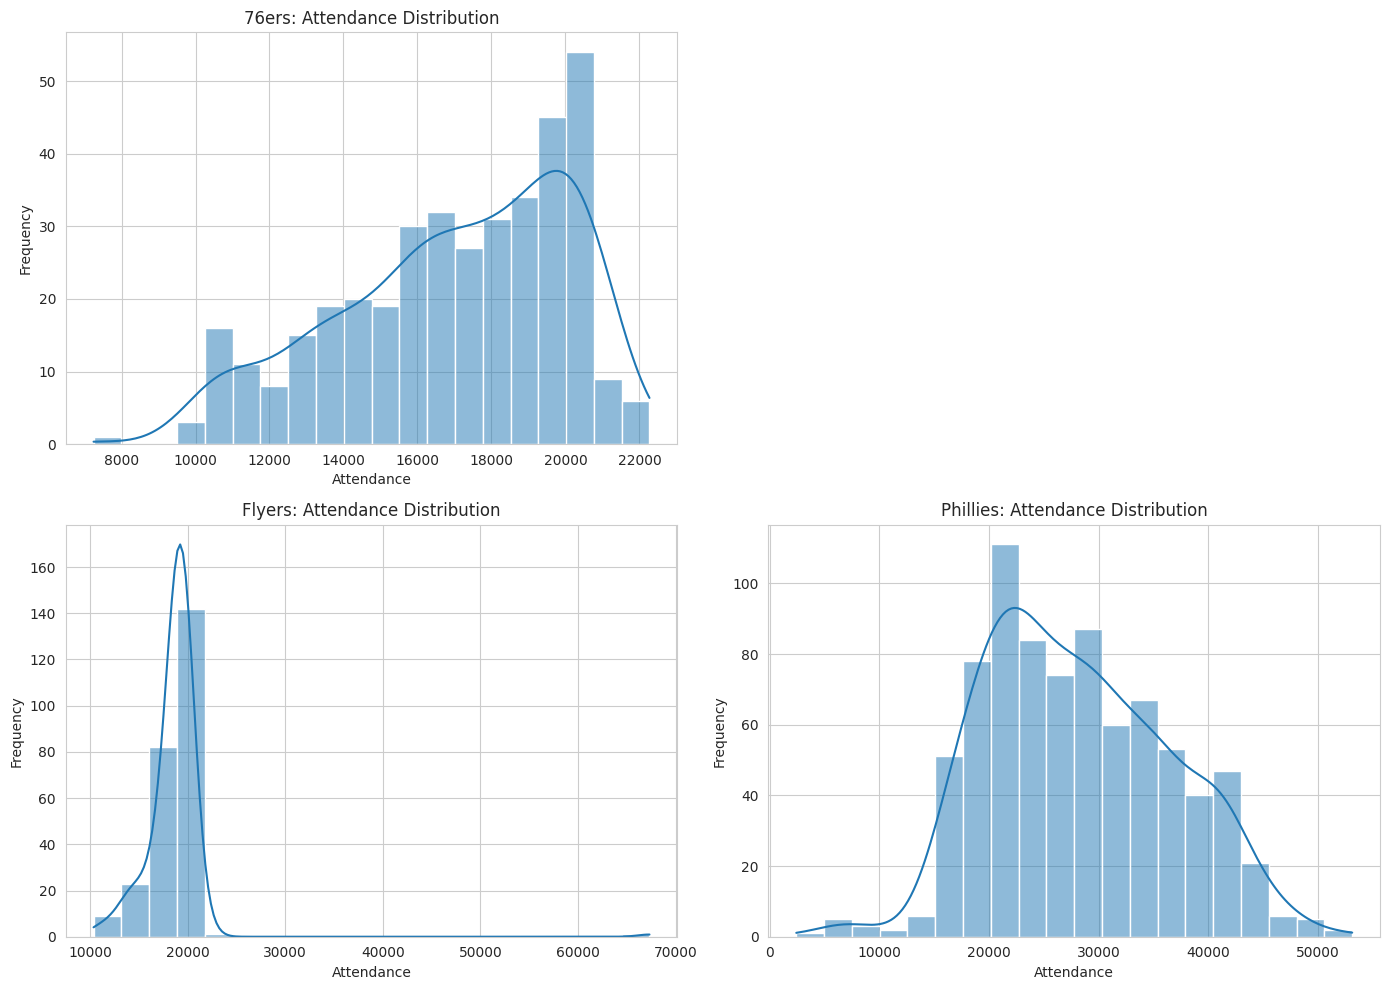

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=False)

for ax, (team_name, df) in zip(axes.flatten(), teams.items()):
    if "Attendance" in df.columns:
        sns.histplot(df["Attendance"], bins=20, kde=True, ax=ax)
        ax.set_title(f"{team_name}: Attendance Distribution")
        ax.set_xlabel("Attendance")
        ax.set_ylabel("Frequency")
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()